In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)

In [2]:
digits = load_digits()

X = digits.data / 16.0   # normalize
y = digits.target

# one-hot encoding
def one_hot(y, num_classes=10):
    encoded = np.zeros((y.size, num_classes))
    encoded[np.arange(y.size), y] = 1
    return encoded

y_encoded = one_hot(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=0
)

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax(z):
    exp_vals = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

In [4]:
def train_mlp(X_train, y_train, lr=0.1, epochs=100, l2_lambda=0):
    
    input_size = 64
    hidden_size = 32
    output_size = 10
    
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    
    losses = []
    
    for epoch in range(epochs):
        
        z1 = np.dot(X_train, W1) + b1
        a1 = relu(z1)
        
        z2 = np.dot(a1, W2) + b2
        y_pred = softmax(z2)
        
        loss = -np.mean(np.sum(y_train * np.log(y_pred + 1e-8), axis=1))
        
        # add L2 regularization if lambda > 0
        loss += l2_lambda * (np.sum(W1**2) + np.sum(W2**2))
        
        losses.append(loss)
        
        d_z2 = (y_pred - y_train) / y_train.shape[0]
        
        dW2 = np.dot(a1.T, d_z2) + 2 * l2_lambda * W2
        db2 = np.sum(d_z2, axis=0, keepdims=True)
        
        d_hidden = np.dot(d_z2, W2.T) * relu_derivative(z1)
        
        dW1 = np.dot(X_train.T, d_hidden) + 2 * l2_lambda * W1
        db1 = np.sum(d_hidden, axis=0, keepdims=True)
        
        W2 -= lr * dW2
        b2 -= lr * db2
        
        W1 -= lr * dW1
        b1 -= lr * db1
    
    return W1, b1, W2, b2, losses

In [5]:
# SGD baseline
W1_sgd, b1_sgd, W2_sgd, b2_sgd, loss_sgd = train_mlp(X_train, y_train)

# Smaller learning rate
W1_lr, b1_lr, W2_lr, b2_lr, loss_lr = train_mlp(X_train, y_train, lr=0.01)

# L2 regularization
W1_l2, b1_l2, W2_l2, b2_l2, loss_l2 = train_mlp(X_train, y_train, l2_lambda=0.001)

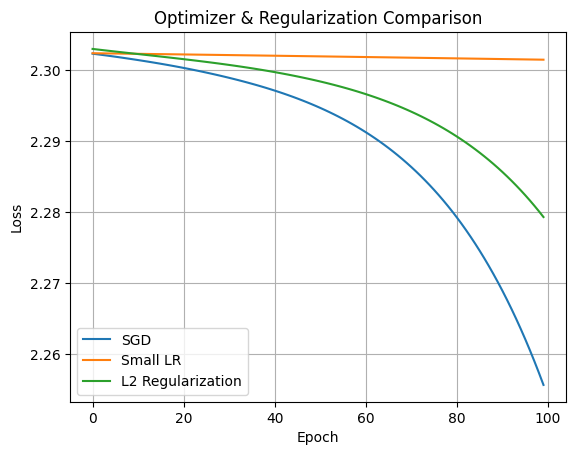

In [6]:
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_lr, label="Small LR")
plt.plot(loss_l2, label="L2 Regularization")

plt.legend()
plt.title("Optimizer & Regularization Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()